PRIYANKA MURUGAN

TRACK: DATA ANALYTICS

LEVEL 2(TASK 1):  Predicting House Prices with Linear Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/House Price Prediction Dataset.csv")
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [ ]:
df.shape

(2000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


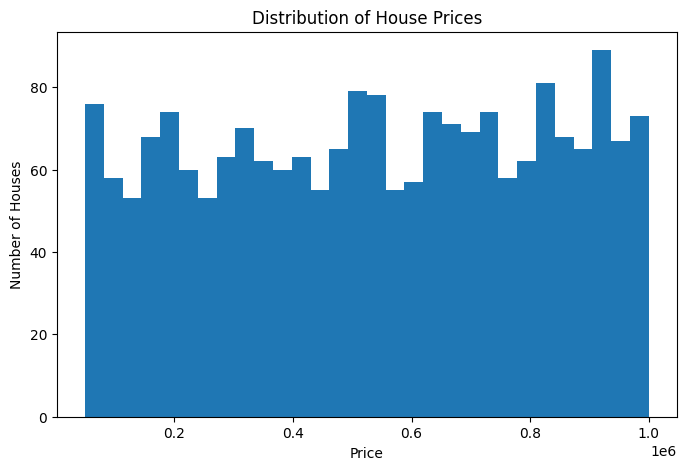

In [ ]:

plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.show()

Features= All columns but no price (X)
Targert = price columns (Y)

In [ ]:
X = df.drop("Price", axis=1)

In [ ]:
Y=df['Price']

In [ ]:
print(X.head())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage  
0     No  
1     No  
2     No  
3    Yes  
4    Yes  


In [ ]:
print(Y.head())

0    149919
1    424998
2    266746
3    244020
4    636056
Name: Price, dtype: int64


In [ ]:
X.dtypes

,0
Id,int64
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Location,object
Condition,object
Garage,object


In [ ]:
X = pd.get_dummies(X)
X = X.astype(int)

In [ ]:
X.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban,Condition_Excellent,Condition_Fair,Condition_Good,Condition_Poor,Garage_No,Garage_Yes
0,1,1360,5,4,3,1970,1,0,0,0,1,0,0,0,1,0
1,2,4272,5,4,3,1958,1,0,0,0,1,0,0,0,1,0
2,3,3592,2,2,3,1938,1,0,0,0,0,0,1,0,1,0
3,4,966,4,2,2,1902,0,0,1,0,0,1,0,0,0,1
4,5,4926,1,4,2,1975,1,0,0,0,0,1,0,0,0,1


In [ ]:
correlation = df.corr(numeric_only=True)

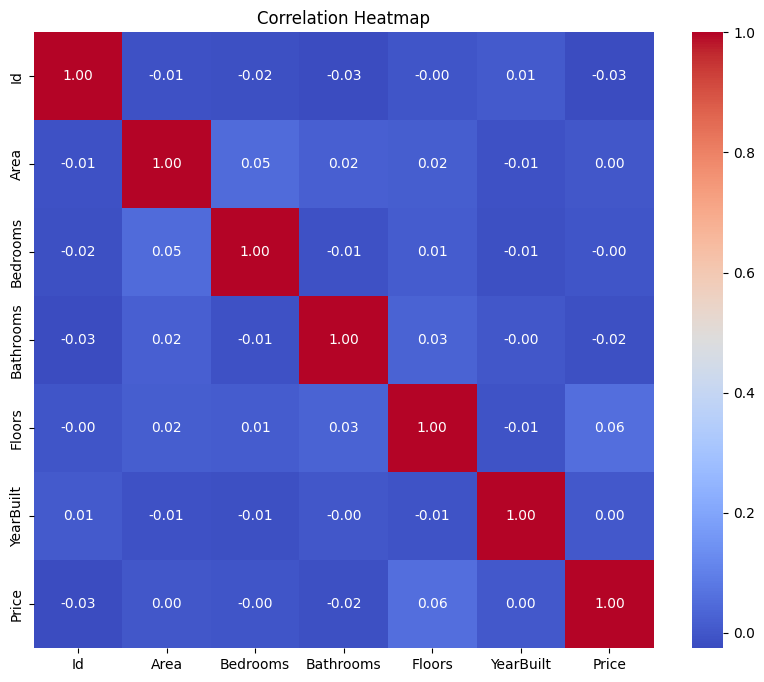

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(1600, 16)
(400, 16)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
prediction = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

prediction.head(10)

,Actual Price,Predicted Price
1860,514764,511317.731099
353,694256,557359.556529
1333,66375,482838.345234
905,650243,540695.641120
1289,223285,549288.502441
1273,468127,518144.169284
938,513002,523405.402360
1731,911525,568346.516278
65,723265,556990.397727
1323,339416,573402.718460


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R² Score
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 78279764120.86243
Root Mean Squared Error (RMSE): 279785.21069002635
R² Score: -0.006181784611834162


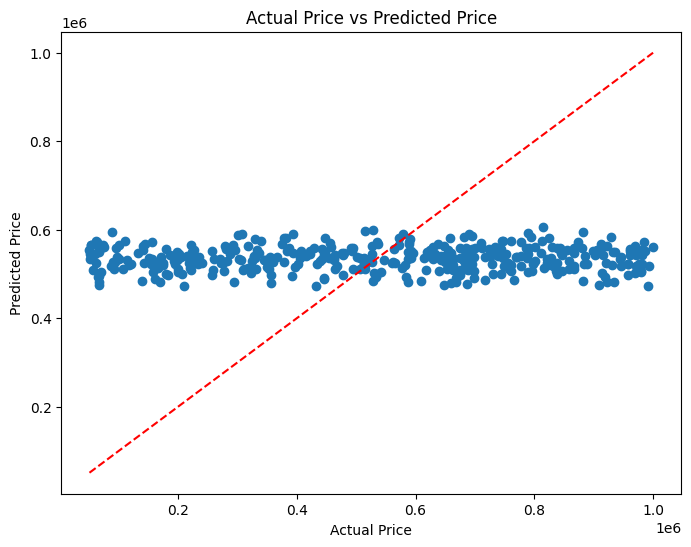

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")

plt.show()

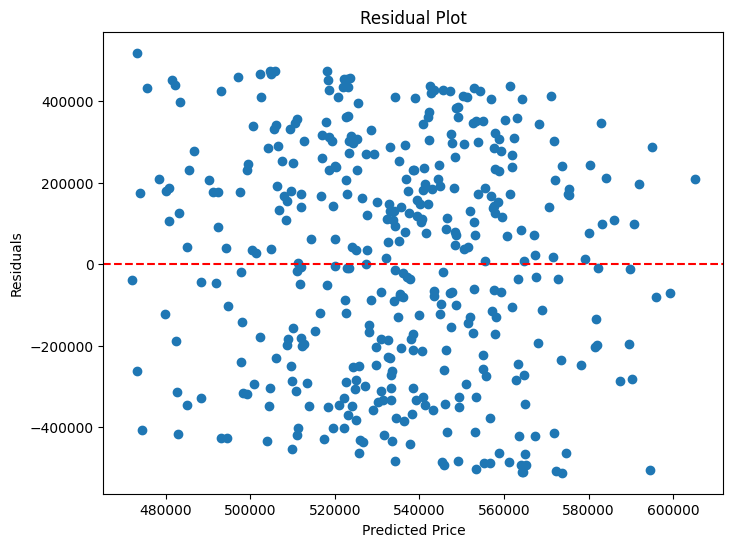

In [ ]:
# Calculate residuals
residuals = y_test - y_pred

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Id,-12.007473
1,Area,-0.484192
2,Bedrooms,53.249124
3,Bathrooms,-9835.704344
4,Floors,23582.408499
5,YearBuilt,116.775334
6,Location_Downtown,-83.754276
7,Location_Rural,1742.712612
8,Location_Suburban,11026.385579
9,Location_Urban,-12685.343915
